<a href="https://colab.research.google.com/github/Rimal-Rimal/AI/blob/main/ClassificationModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import RFE

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/food_hygiene_rating_data.csv"

df = pd.read_csv(file_path)

df = df.drop_duplicates()
df = df.dropna()

high_memory_cols = [
    "BusinessName",
    "AddressLine1",
    "AddressLine2",
    "AddressLine3",
    "PostCode",
    "LocalAuthorityName",
    "LocalAuthorityWebsite",
    "LocalAuthorityEmailAddress",
    "FHRSID",
    "LocalAuthorityBusinessID"
]

df = df.drop(columns=high_memory_cols, errors="ignore")

df["RatingValue"] = pd.to_numeric(df["RatingValue"], errors="coerce")

df = df.dropna()

df = df.sample(min(len(df), 20000), random_state=42)

print(df.shape)


(20000, 8)


In [ ]:
X = df.drop("RatingValue", axis=1)
y = df["RatingValue"]

le = LabelEncoder()

for col in X.select_dtypes(include="object"):
    X[col] = le.fit_transform(X[col].astype(str))

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
lr = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=500,
    random_state=42
)

lr.fit(X_train, y_train)

rf.fit(X_train, y_train)

mlp.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
lr_pred = lr.predict(X_test)

rf_pred = rf.predict(X_test)

mlp_pred = mlp.predict(X_test)

def evaluate(name, y_true, y_pred):

    print(name)

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision:", precision_score(y_true, y_pred, average="weighted"))

    print("Recall:", recall_score(y_true, y_pred, average="weighted"))

    print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))

    print()

evaluate("Logistic Regression", y_test, lr_pred)

evaluate("Random Forest", y_test, rf_pred)

evaluate("Neural Network", y_test, mlp_pred)


Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Random Forest
Accuracy: 0.99775
Precision: 0.9978768796992481
Recall: 0.99775
F1 Score: 0.9976128489772157

Neural Network
Accuracy: 0.99975
Precision: 0.9997502893518518
Recall: 0.99975
F1 Score: 0.9997500463544486



In [ ]:
rfe = RFE(lr, n_features_to_select=8)

rfe.fit(X_train, y_train)

X_train_rfe = rfe.transform(X_train)

X_test_rfe = rfe.transform(X_test)


In [ ]:
param_grid = {

    "n_estimators": [50, 100],

    "max_depth": [None, 10],

    "min_samples_split": [2, 5]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=3,

    scoring="accuracy"

)

grid.fit(X_train_rfe, y_train)

best_rf = grid.best_estimator_

print(grid.best_params_)


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
final_pred = best_rf.predict(X_test_rfe)

evaluate("Final Optimized Random Forest", y_test, final_pred)


Final Optimized Random Forest
Accuracy: 0.99675
Precision: 0.9970582219687093
Recall: 0.99675
F1 Score: 0.9964021669230119



In [ ]:
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "Random Forest",

        "Neural Network",

        "Optimized Random Forest"

    ],

    "Accuracy": [

        accuracy_score(y_test, lr_pred),

        accuracy_score(y_test, rf_pred),

        accuracy_score(y_test, mlp_pred),

        accuracy_score(y_test, final_pred)

    ],

    "Precision": [

        precision_score(y_test, lr_pred, average="weighted"),

        precision_score(y_test, rf_pred, average="weighted"),

        precision_score(y_test, mlp_pred, average="weighted"),

        precision_score(y_test, final_pred, average="weighted")

    ],

    "Recall": [

        recall_score(y_test, lr_pred, average="weighted"),

        recall_score(y_test, rf_pred, average="weighted"),

        recall_score(y_test, mlp_pred, average="weighted"),

        recall_score(y_test, final_pred, average="weighted")

    ],

    "F1 Score": [

        f1_score(y_test, lr_pred, average="weighted"),

        f1_score(y_test, rf_pred, average="weighted"),

        f1_score(y_test, mlp_pred, average="weighted"),

        f1_score(y_test, final_pred, average="weighted")

    ]

})

print(results)


                     Model  Accuracy  Precision   Recall  F1 Score
0      Logistic Regression   1.00000   1.000000  1.00000  1.000000
1            Random Forest   0.99775   0.997877  0.99775  0.997613
2           Neural Network   0.99975   0.999750  0.99975  0.999750
3  Optimized Random Forest   0.99675   0.997058  0.99675  0.996402


In [ ]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

print(df["RatingValue"].value_counts())


       Unnamed: 0                         BusinessType  RatingValue  \
539           539            School/college/university          5.0   
4333         1894                    Pub/bar/nightclub          5.0   
22495        1084  Hospitals/Childcare/Caring Premises          5.0   
22547        1136                    Retailers - other          1.0   
4921           28            Distributors/Transporters          5.0   

          RatingKey  RatingDate  LocalAuthorityCode  Longitude   Latitude  
539    fhrs_5_en-GB  2019-01-14                 525   0.011217  51.516385  
4333   fhrs_5_en-GB  2019-03-20                 519  -0.114326  51.570068  
22495  fhrs_5_en-GB  2017-04-25                 517  -0.409785  51.601513  
22547  fhrs_1_en-GB  2021-06-17                 517  -0.409838  51.601385  
4921   fhrs_5_en-GB  2021-03-24                 508  -0.081234  51.517358  
(20000, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 539 to 6516
Data columns (total 8 columns):
 #

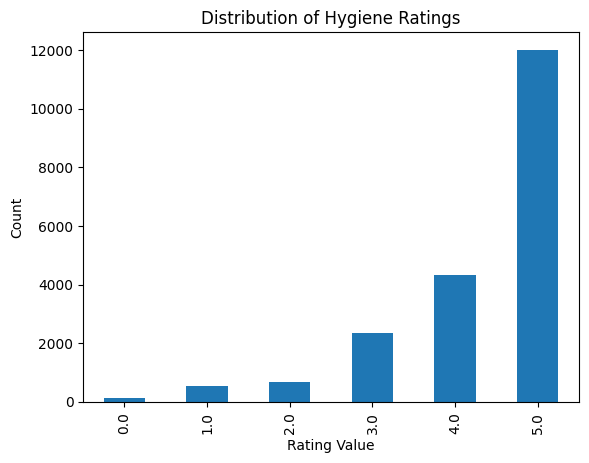

In [ ]:
plt.figure()

df["RatingValue"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Hygiene Ratings")

plt.xlabel("Rating Value")

plt.ylabel("Count")

plt.show()


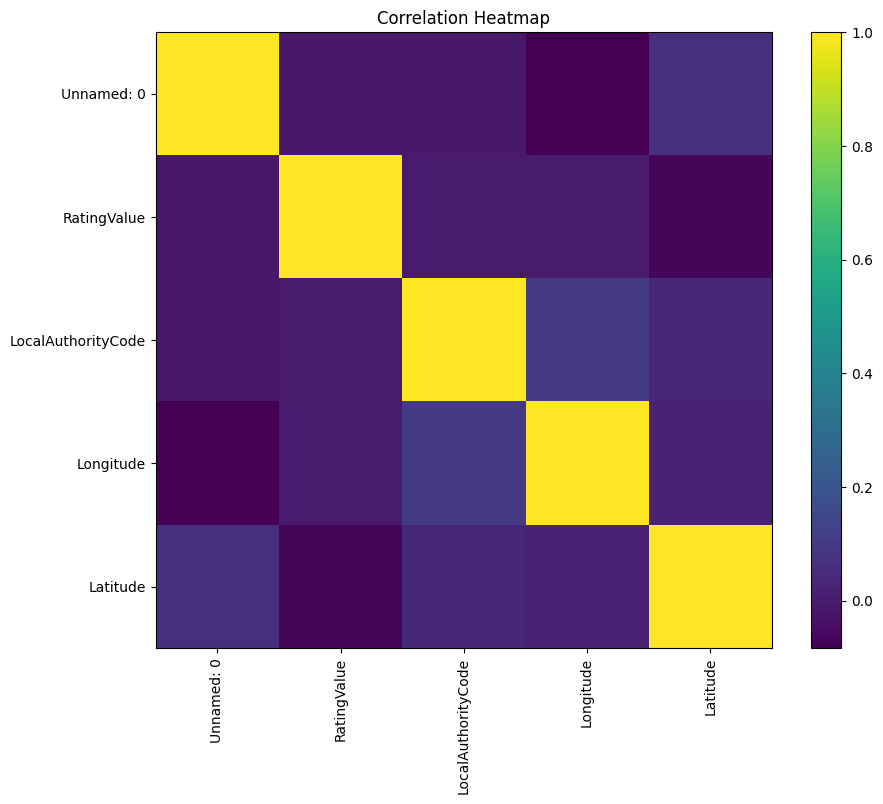

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

plt.imshow(numeric_df.corr())

plt.colorbar()

plt.title("Correlation Heatmap")

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)

plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.show()


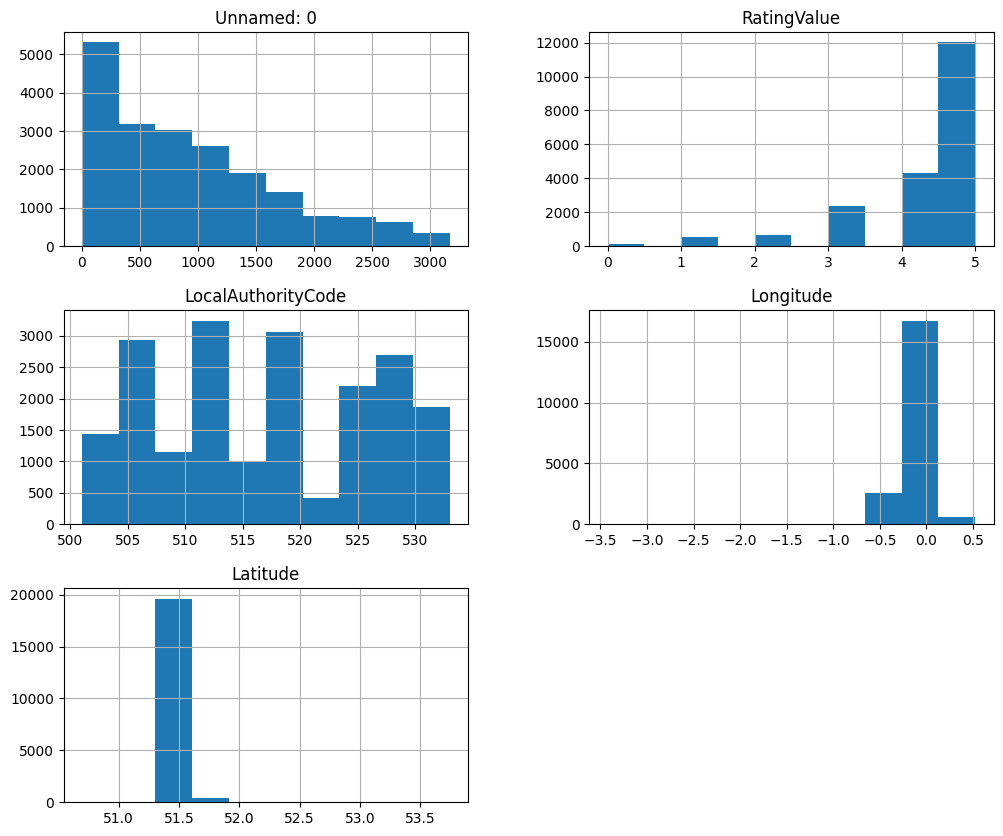

In [ ]:
numeric_df.hist(figsize=(12,10))

plt.show()


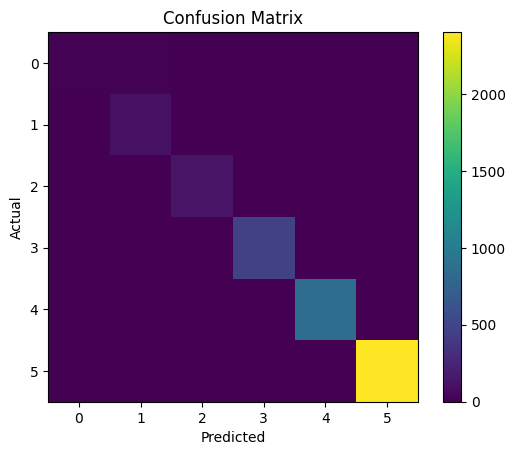

[[  15   12    0    0    0    0]
 [   0  105    0    0    0    0]
 [   0    0  131    1    0    0]
 [   0    0    0  471    0    0]
 [   0    0    0    0  863    0]
 [   0    0    0    0    0 2402]]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred)

plt.figure()

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(cm)


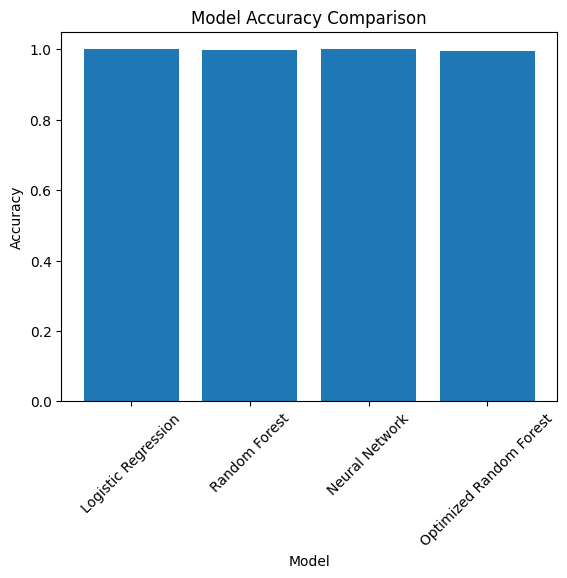

In [ ]:
models = [

    "Logistic Regression",

    "Random Forest",

    "Neural Network",

    "Optimized Random Forest"

]

accuracies = [

    accuracy_score(y_test, lr_pred),

    accuracy_score(y_test, rf_pred),

    accuracy_score(y_test, mlp_pred),

    accuracy_score(y_test, final_pred)

]

plt.figure()

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()


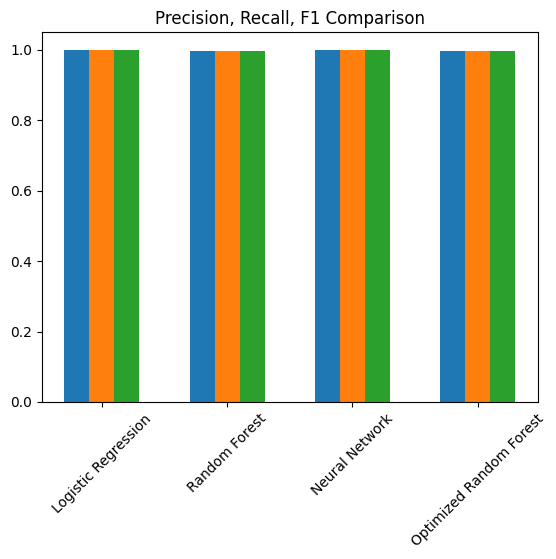

In [ ]:
precision = [

    precision_score(y_test, lr_pred, average="weighted"),

    precision_score(y_test, rf_pred, average="weighted"),

    precision_score(y_test, mlp_pred, average="weighted"),

    precision_score(y_test, final_pred, average="weighted")

]

recall = [

    recall_score(y_test, lr_pred, average="weighted"),

    recall_score(y_test, rf_pred, average="weighted"),

    recall_score(y_test, mlp_pred, average="weighted"),

    recall_score(y_test, final_pred, average="weighted")

]

f1 = [

    f1_score(y_test, lr_pred, average="weighted"),

    f1_score(y_test, rf_pred, average="weighted"),

    f1_score(y_test, mlp_pred, average="weighted"),

    f1_score(y_test, final_pred, average="weighted")

]

x = np.arange(len(models))

width = 0.2

plt.figure()

plt.bar(x, precision, width)

plt.bar(x + width, recall, width)

plt.bar(x + 2*width, f1, width)

plt.xticks(x + width, models, rotation=45)

plt.title("Precision, Recall, F1 Comparison")

plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, final_pred)

print(f"Final Accuracy: {final_accuracy:.4f}")


Final Accuracy: 0.9968
